In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro, kstest, probplot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot

## Carga dos dados


In [2]:
# Carregar o dataset
df_pontuacao = pd.read_csv('./dataset/estudo.csv')

In [3]:
# Checar estrutura do DataFrame
df_pontuacao.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   horas_estudo     101 non-null    float64
 1   pontuacao_teste  101 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [4]:
# Visualizar topo do DF
df_pontuacao.head(5)

,horas_estudo,pontuacao_teste
0,1.1,30
1,2.0,55
2,2.5,60
3,3.6,75
4,4.2,85


In [ ]:
# Visualizar o final do DF
df_pontuacao.tail(5)

,horas_estudo,pontuacao_teste
96,46.0,780
97,46.2,785
98,46.4,790
99,46.6,795
100,46.9,800


## EDA (Análise Exploratória dos Dados)

In [7]:
# Medidas estatísticas das variáveis
df_pontuacao.describe()

,horas_estudo,pontuacao_teste
count,101.000000,101.000000
mean,28.604950,455.000000
std,14.116128,221.385411
min,1.100000,30.000000
25%,16.500000,270.000000
50%,30.900000,465.000000
75%,41.800000,655.000000
max,46.900000,800.000000


<Axes: xlabel='horas_estudo', ylabel='pontuacao_teste'>

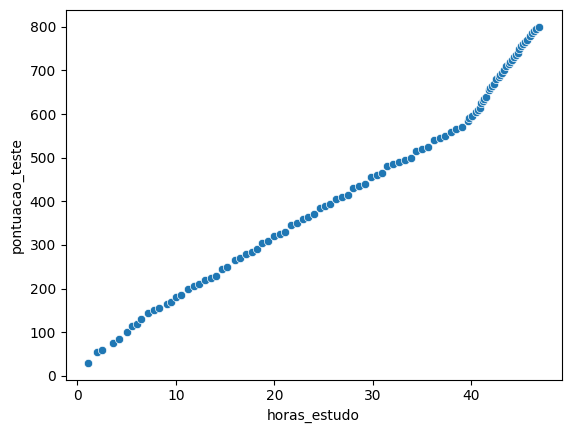

In [8]:
# Plot de Dispersão
# X = horas_estudo
# Y = pontuacao_teste
sns.scatterplot(data=df_pontuacao, x='horas_estudo', y='pontuacao_teste')

<Axes: ylabel='horas_estudo'>

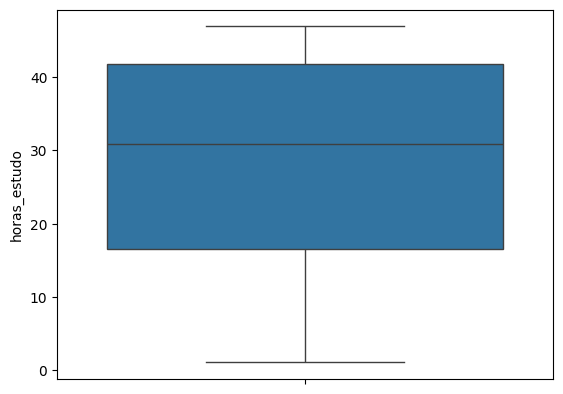

In [9]:
# Verificar se temos outliers (BoxPlot)
sns.boxplot(df_pontuacao, y='horas_estudo')

<Axes: ylabel='pontuacao_teste'>

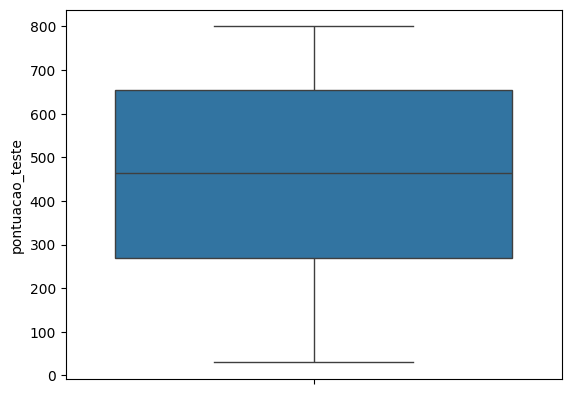

In [10]:
# Verificar se temos outliers (BoxPlot)
sns.boxplot(df_pontuacao, y='pontuacao_teste')

<Axes: >

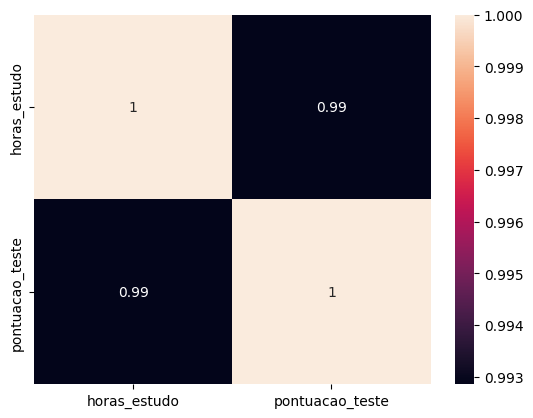

In [11]:
# Verificar Correlação - Pearson
sns.heatmap(df_pontuacao.corr('pearson'), annot=True)

<Axes: >

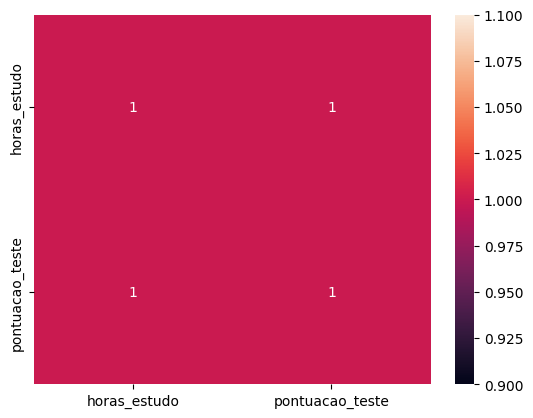

In [12]:
# Verificar Correlação - Spearman
sns.heatmap(df_pontuacao.corr('spearman'), annot=True)

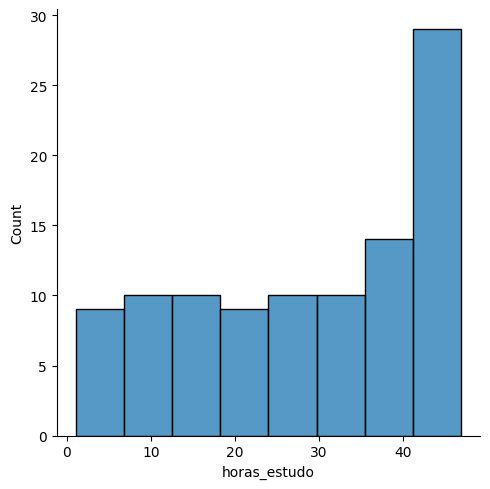

In [13]:
# Histograma das variáveis
sns.displot(df_pontuacao, x='horas_estudo')

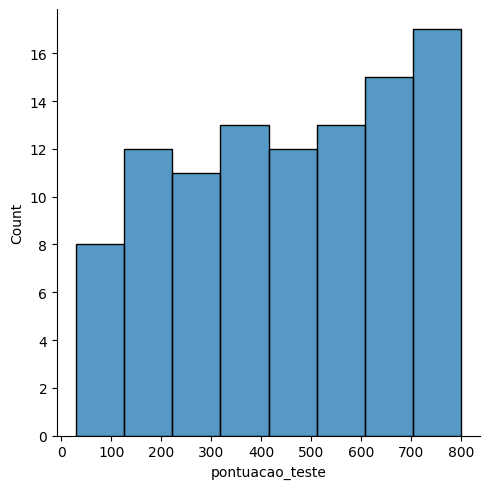

In [14]:
# Histograma das variáveis
sns.displot(df_pontuacao, x='pontuacao_teste')

## Treinamento do modelo

In [61]:
# Divisão do dataset entre treino e teste
# Quando temos apenas um feature, precisamos ajustar o shape
X = df_pontuacao.horas_estudo.values.reshape(-1, 1)
y = df_pontuacao.pontuacao_teste.values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=50)

In [62]:
# Instanciar o modelo a ser treinado
reg_model = LinearRegression()

In [63]:
# Treinar o modelo
reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
# Imprimir a equação da reta
# y = aX + b
print("A equação da reta é: y = {:4f}x + {:4f}".format(reg_model.coef_[0][0], reg_model.intercept_[0]))

A equação da reta é: y = 15.642619x + 8.476601


## Validação do modelo

#### Análise de métricas - MAE, MSE e RMSE

In [65]:
# Predição dos valores com base no conjunto de testes
y_pred = reg_model.predict(X_test)

In [66]:
# Calcular métrica R-squared ou Coeficiente de Determinação
# R2 representa a proporção na variação dependente que é explicada pela variável independente
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
r2_score(y_test, y_pred)

0.9828400452912442

In [67]:
# Calcular métrica MAE - Mean Absolute Error
# MAE = Media (y_test - y_pred)
# É uma métrica fácil de interpretar
# MAE é menos sensível a outliers
mean_absolute_error(y_test, y_pred)

22.957470277134615

In [68]:
# MSE (Mean Squared Error)
# MSE = Media (y_test - y_pred)²
# Não é uma métrica fácil de interpretar
# é mais sensível a outliers e penaliza grandes erros
mean_squared_error(y_test, y_pred)


766.9972992416427

In [69]:
# RMSE (Square Root Mean Squared Error)
# RMSE = Raiz (Media (y_test - y_pred)²)
# É uma métrica fácil de interpretar
# é sensível a outliers e penaliza grandes erros
root_mean_squared_error(y_test, y_pred)


27.69471608884342

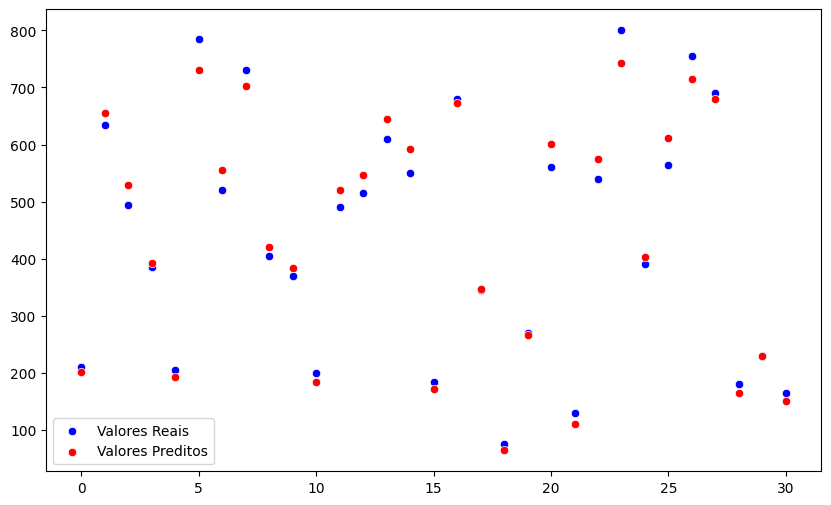

In [70]:
# Analise Gráfica
x_axis = range(len(y_test))
plt.figure(figsize=(10,6))
sns.scatterplot(x=x_axis, y=y_test.reshape(-1), color='blue', label='Valores Reais')
sns.scatterplot(x=x_axis, y=y_pred.reshape(-1), color='red', label='Valores Preditos')
plt.legend()
plt.show()


## Análise de Resíduos

In [71]:
# Calcular residuos
residuos = y_test - y_pred

In [72]:
# Calcular os residuos padronizados (standardization)
# Para cada elemento de um conjunto (X - media) / desvio-padrao
from scipy.stats import zscore
residuos_std = zscore(residuos)

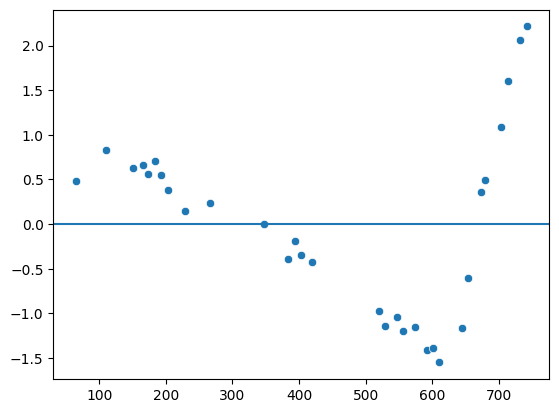

In [ ]:
# Verificar linearidade do modelo:
# Se os residuos estiverem entre -2 e +2 (na escala padrão) - indica linearidade

# Verificar a homogeneidade das variancias (Homocesticidade)
# Valores estiver na em torno da reta, temos homocedasticidade, caso contrario, temos alguma tendencia ou padrao (formam cone ou funil), há heterocedasticidade
sns.scatterplot(x=y_pred.reshape(-1), y=residuos_std.reshape(-1))
plt.axhline(y=0)

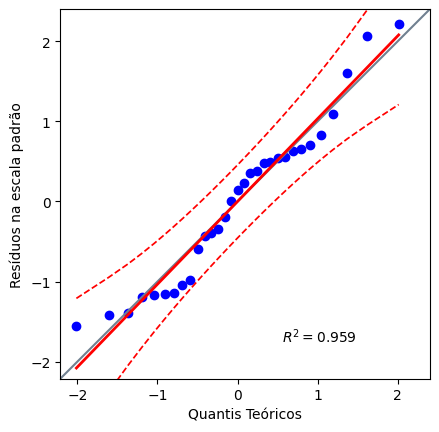

In [74]:
# Checar se residuos seguem uma distribuição normal
# QQ (Quantile-Quantile) Plot
import pingouin as pg
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel("Quantis Teóricos")
plt.ylabel('Resíduos na escala padrão')
plt.show()

## Teste de Normalidade de Residuos

In [75]:
# Teste de Shapiro Wilk
# H0 - segue distribuição normal
# H1 - não segue distribuição normal
# Se p-valor > 0.05 não rejeita H0, caso contrario rejeita
stat_shapiro, p_value_shapiro = shapiro(residuos.reshape(-1))
print("Estatística do teste: {} e P-valor: {}".format(stat_shapiro, p_value_shapiro))

Estatística do teste: 0.9500532226161759 e P-valor: 0.15663817850304973


In [76]:
# Teste de Kolmogorov-Smirnov
# H0 - segue distribuição normal
# H1 - não segue distribuição normal
# Se p-valor > 0.05 não rejeita H0, caso contrario rejeita
stat_ks, p_value_ks = kstest(residuos.reshape(-1), 'norm')
print("Estatística do teste: {} e P-valor: {}".format(stat_ks, p_value_ks))

Estatística do teste: 0.48355808450512827 e P-valor: 3.395368995814077e-07


## Fazendo Predições

In [82]:
# Se eu estudar 30.4 horas, qual a pontuação prevista pelo modelo?
reg_model.predict([[30.4]])

array([[484.01220436]])

In [79]:
# Quantas horas eu deveria estudar, para obter 600 pontos (modelo)
# y = ax + b
# y - b = ax
# x = (y - b) / a
horas = (600 - reg_model.intercept_[0]) / reg_model.coef_[0][0]
print(horas)

37.81485802710669


## Salvar modelo para usar depois

In [80]:
import joblib
joblib.dump(reg_model, './modelo_regressao.pkl')

['./modelo_regressao.pkl']